## "BIG FUNCTION"!

A comprehensive notebook to generate tensors, build and train a CNN, conduct XAI integrated gradient work, and save results.

### Imports and File Stitching 

In [3]:
# Imports
import os
import netCDF4 as nc
import pandas as pd
import numpy as np
import xarray as xr
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import re
import matplotlib.pyplot as plt


# Control which user's files are accessed
match_sk = 'sophiekim'
match_hc = 'hayeonchung'
match_ck = 'Caroline'
match_st = 'student'
path_str = os.getcwd()
print(path_str)
if re.search(match_sk, path_str):
    os.chdir("/Users/sophiekim/Desktop/2_research/MamalakisResearch") 
    user = match_sk
    print("Sophie Kim recognized as user.")
elif re.search(match_hc, path_str):
    os.chdir("/Users/hayeonchung/Downloads/Mamalakis Graduate Research/MamalakisResearch") 
    user = match_hc
    print("Hayeon Chung recognized as user.")
elif re.search(match_st, path_str):
    os.chdir("/Users/student/Desktop/mamalakis_research/MamalakisResearch") # Caroline's computer
    user = "carolinekranefuss"
    print("Caroline Kranefuss recognized as user.")
elif re.search(match_ck, path_str):
    os.chdir("/Users/Caroline/Desktop/school/MamalakisResearch") 
    user = "carolinekranefuss2"
    print("Caroline Kranefuss 2 recognized as user.")
else:
    print("User not recognized. Please manually change to parent repository directory 'MamalakisResearch'.")

/Users/sophiekim/Desktop/2_research/MamalakisResearch
Sophie Kim recognized as user.


In [4]:
# Assign base path
base_path = os.getcwd()

# All users should have locally loaded 'data' folder
data_path = base_path + '/data/'

In [5]:
%%capture
%run "get_cnn_tensors_v3.ipynb" 

### XAI/Integrated Gradient Work

In [6]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations on GradientTape
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss       
    grads = tape.gradient(preds, inputs)

    return grads

In [7]:
def get_integrated_gradients(inputs, model, baseline=None, num_steps=100, top_pred_idx=None):
    # Ensure inputs and baseline are float32
    inputs = inputs.astype(np.float32)
    
    if baseline is None:
        # Fallback to zeros if no baseline provided
        baseline = np.zeros_like(inputs).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)
        # Ensure baseline has a leading dimension if it's a single mean map
        if baseline.ndim == inputs.ndim - 1:
            baseline = np.expand_dims(baseline, axis=0)

    # Generate interpolation steps
    # We use np.linspace to create the scaling factors (alphas)
    alphas = np.linspace(0.0, 1.0, num_steps + 1)
    
    # Compute Gradients along the path
    # We iterate through the interpolation path from baseline to input
    all_grads = []
    for alpha in alphas:
        # Interpolate: baseline + alpha * (input - baseline)
        step_input = baseline + alpha * (inputs - baseline)
        
        # Get gradients for this specific step
        grad = get_gradients(step_input, model, top_pred_idx=top_pred_idx)
        all_grads.append(grad)
    
    # Convert to tensor for averaging
    # Shape: (num_steps + 1, batch, vars, lat, lon)
    all_grads = tf.convert_to_tensor(all_grads, dtype=tf.float32)

    # Approximate the integral (Trapezoidal Rule)
    # Average the gradients of adjacent steps
    grads_at_step_ends = (all_grads[:-1] + all_grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_at_step_ends, axis=0)

    # Final IG calculation: (input - baseline) * average gradient
    integrated_grads = (inputs - baseline) * avg_grads.numpy()
    
    return integrated_grads

### Training the CNN

In [8]:
def cnn_training(X_data, y_data, learning_rate=0.0001, epochs=500, batch_size=64):
    # prep indices
    n_samples = X_data.shape[0]
    indices = np.arange(n_samples) # [0, 1, 2, ..., N-1]

    X = np.transpose(X_data, (0, 2, 3, 1))  # (N, lat, lon, 7)
    y = y_data.astype(np.float32)           # (N, 1)

    
    # split test set (50 samples) 
        # passing indices to keep track of the indices that are going in the set 
    X_rem, X_test, y_rem, y_test, idx_rem, test_indices = train_test_split(
        X, y, indices,
        test_size=50,
        stratify=y
    )

    # val split (from remaning 450 samples)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X_rem, y_rem, idx_rem,
        test_size=50,
        stratify=y_rem
    )

    
    lat, lon = X_train.shape[1], X_train.shape[2]
    model = models.Sequential([
        layers.Input(shape=(lat, lon, 6)),
        
        #  CNN block (64 filters) with two convs, then pool
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 32 kernels (conv + pool)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 16 kernels (conv only)
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),             
        layers.Dense(50, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=2
    )

    # train model 
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Return everything needed for the large loop
    return model, X_train, y_train, X_test, y_test, test_indices, history

### Function to Save Results

In [9]:
def save_iteration_netcdf(ig_data, y_true, y_pred, late_test_idx, test_idx, scenario, early, late, filename, exact_baseline_prediction):
    """
    Saves a single iteration's spatial heatmaps to NetCDF.
    Squeezes 4D tensors to 3D to ensure Xarray dimension compatibility.
    """
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    test_idx_filtered = test_idx[late_test_idx]
    scalar_baseline = exact_baseline_prediction.item() # making it one number instead of 2d array


    ds = xr.Dataset(
        data_vars={
            "ig_heatmaps": (("sample", "lat", "lon", "feature"), ig_data),
            "y_true": (("sample",), y_true),
            "y_pred": (("sample",), y_pred), 
            "test_idx_filtered": (("sample",), test_idx_filtered), 
            "exact_baseline_prediction": ((), scalar_baseline)
        },
        coords={
            "scenario": scenario,
            "early_yr": early,
            "late_yr": late
        }
    )
    
    ds.to_netcdf(filename)

### Running Experiment - Putting it all Together!

In [10]:
def run_climate_experiment(scenarios, early_starts, model_list, data_path):

    # Get a run number from user for use when saving files
    run_num = input("What run number are you on? ")

    # initializing list to store results from each early/late period iteration
    all_results = []

    # Loop through scenarios:
    for scenario in scenarios:
    
        # Loop though early starts
        for early_start in early_starts:

            # make late period start years as 10 plus the early start year, going up to 2095
            late_starts = np.arange(early_start + 10, 2095, 10) 
            
            # Loop through late starts
            for late_start in late_starts:

                print(f"Processing: {scenario} | Early: {early_start} | Late: {late_start}")

                # prepping data for every early and late 10yr time period combo 
                X_data, y_data, _ = get_cnn_tensors(
                    model_list, scenario, data_path, 
                    st_early=early_start, end_early=early_start+9, 
                    st_late=late_start, end_late=late_start+9
                )
                
                # training data with history for loss curve
                model, X_train, y_train, X_test, y_test, test_idx, history = cnn_training(X_data, y_data)

                if history is not None and hasattr(history, 'history'):
                    plt.figure(figsize=(8, 4))
                    plt.plot(history.history['loss'], label='Training Loss', color='blue')
                    if 'val_loss' in history.history:
                        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
                    
                    plt.title(f"Loss Curve: {scenario} ({early_start} vs {late_start})")
                    plt.xlabel("Epochs")
                    plt.ylabel("Loss")
                    plt.legend()
                    plt.grid(True, linestyle='--', alpha=0.6)
                    
                    plt.show()      
                    plt.close()     
                else:
                    print("something went wrong with loss plot")
                
                # predicting
                preds = model.predict(X_test).flatten()

                # --- CALCULATE ACCURACY ---
                # Convert probabilities to binary 0 or 1 using 0.5 as threshold
                binary_preds = (preds >= 0.5).astype(int)
                # Compare to y_test (flattened to match shapes)
                accuracy = np.mean(binary_preds == y_test.flatten())
                
                print(f"--> Iteration Accuracy: {accuracy:.2%}")
                
                # XAI STUFF: 
                # baseline is the mean of early period from training set
                early_idx = np.where(y_train == 0)[0]
                baseline = np.mean(X_train[early_idx], axis=0, keepdims=True, dtype = np.float64)

                # NOTE: need to save baseline prediction values 
                exact_baseline_prediction = model.predict(baseline)
                
                # getting late indices for X_test set 
                late_test_idx = np.where(y_test == 1)[0]
                ig_samples = X_test[late_test_idx]
                
                # integrated gradient calculation based on the early period baseline on the late period stuff 
                ig_output = get_integrated_gradients(ig_samples, model, baseline)
                if hasattr(ig_output, 'numpy'): 
                    ig_output = ig_output.numpy()
                
                # getting y test filters 
                y_test_filtered = y_test[late_test_idx].flatten() 
                preds_filtered = preds[late_test_idx]

                nc_filename = f"{base_path}/climate_experiments/result_batches{user}_{run_num}/res_{scenario}_{early_start}_{late_start}.nc"
                
                # Pass the FILTERED data (25 samples) instead of the full test set (50)
                save_iteration_netcdf(ig_output, y_test_filtered, preds_filtered, late_test_idx, test_idx,
                                        scenario, early_start, late_start, nc_filename, exact_baseline_prediction)
                
                final_accuracy = np.mean((preds >= 0.5).astype(int) == y_test.flatten())
                print(f"final accuracy: {final_accuracy: .2%}")

                # making test idx values strings so that can add all the indices for that yr combo iteration as one row in csv file
                test_idx_str = ", ".join(map(str, test_idx))

                all_results.append({
                    'early_yr': early_start,
                    'late_yr': late_start,
                    'scenario': scenario, 
                    'mean_pred': np.mean(preds), 
                    'accuracy': final_accuracy,
                    'test_indices': test_idx_str, 
                   
                })

                ### Question: This seems like the right place to delete, yes?
                del ig_output, X_data, y_data, X_train, y_train, X_test

    if all_results:
        summary_df = pd.DataFrame(all_results)
        summary_df.to_csv(f"{base_path}/climate_experiments/experiment_summary_{user}_{run_num}.csv", mode='a', 
                                   header=not os.path.exists(f"experiment_summary_{user}_{run_num}.csv"), 
                                   index=False)
        print("DONE!")
    
    else:
        print("U MESSED UP!")

Processing: ssp119 | Early: 2015 | Late: 2025
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL


2026-07-26 22:13:31.232210: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-26 22:13:31.232927: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-26 22:13:31.233640: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-26 22:13:31.233720: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-26 22:13:31.234102: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/500


2026-07-26 22:13:33.389684: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 447ms/step - accuracy: 0.5000 - loss: 0.6824 - val_accuracy: 0.5000 - val_loss: 0.6806
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.5000 - loss: 0.6789 - val_accuracy: 0.5000 - val_loss: 0.6770
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - accuracy: 0.5000 - loss: 0.6738 - val_accuracy: 0.5000 - val_loss: 0.6710
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.5000 - loss: 0.6667 - val_accuracy: 0.5000 - val_loss: 0.6646
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 0.5025 - loss: 0.6597 - val_accuracy: 0.5000 - val_loss: 0.6550
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.5050 - loss: 0.6497 - val_accuracy: 0.5200 - val_loss: 0.6431
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 0.5050 - loss: 0.6373 - val_accuracy: 0.5200 - val_loss: 0.6272
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.5125 - loss: 0.6318 - val_accuracy: 0.6000 - val_loss: 0.6

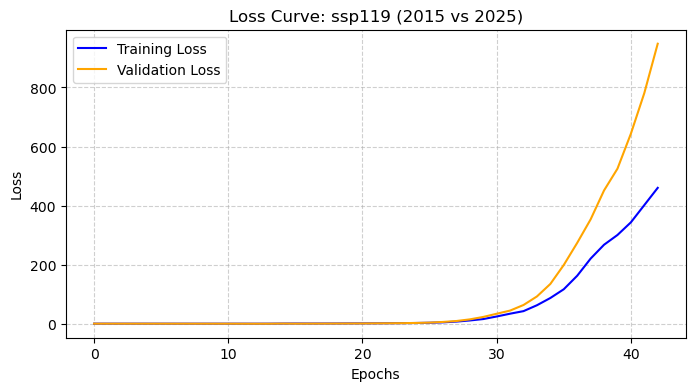

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
--> Iteration Accuracy: 68.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
final accuracy:  68.00%
Processing: ssp119 | Early: 2015 | Late: 2035
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.5000 - loss: 0.6875 - val_accuracy: 0.5000 - val_loss: 0.6788
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.5025 - loss: 0.6721 - val_accuracy: 0.5000 - val_loss: 0.6605
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5000 - loss: 0.6474 - val_accuracy: 0.5000 - val_loss: 0.6344
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5050 - loss: 0.6187 - val_accuracy: 0.5000 - val_loss: 0.6063
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.5175 - loss: 0.5894 - val_accuracy: 0.5000 - val_loss: 0.5704
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6000 - loss: 0.5534 - val_accuracy: 0.5800 - val_loss: 0.5278
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.7225 - loss: 0.5150 - val_accuracy: 0.7600 - val_loss: 0.

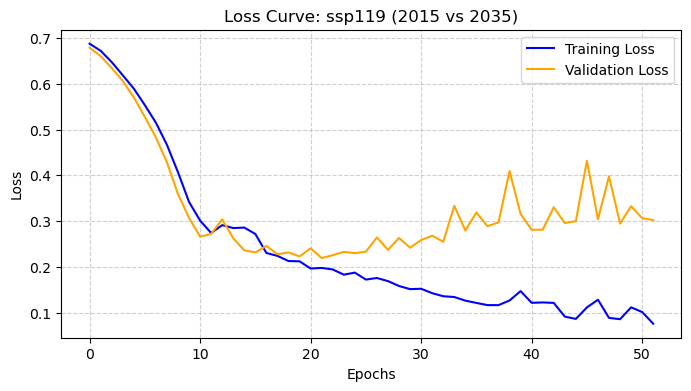

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 467ms/step
--> Iteration Accuracy: 84.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
final accuracy:  84.00%
Processing: ssp119 | Early: 2015 | Late: 2045
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.5000 - loss: 0.7004 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5000 - loss: 0.6996 - val_accuracy: 0.5000 - val_loss: 0.6977
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5000 - loss: 0.7007 - val_accuracy: 0.5000 - val_loss: 0.7002
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5000 - loss: 0.7020 - val_accuracy: 0.5000 - val_loss: 0.7020
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5000 - loss: 0.7032 - val_accuracy: 0.5000 - val_loss: 0.7053
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.4950 - loss: 0.7056 - val_accuracy: 0.5200 - val_loss: 0.7054
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5050 - loss: 0.7032 - val_accuracy: 0.5400 - val_loss: 0.

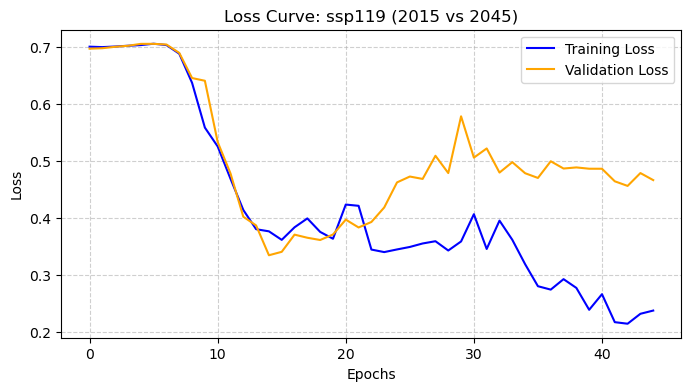

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/stepWARNING:tensorflow:6 out of the last 8 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x37e409870> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
--> Iteration Accuracy: 78.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
final accuracy:  78.00%
Processing: ssp119 | Early: 2015 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.5000 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.6884
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.5250 - loss: 0.6864 - val_accuracy: 0.5000 - val_loss: 0.6869
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.5850 - loss: 0.6824 - val_accuracy: 0.5200 - val_loss: 0.6808
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6050 - loss: 0.6747 - val_accuracy: 0.5200 - val_loss: 0.6702
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5575 - loss: 0.6598 - val_accuracy: 0.5600 - val_loss: 0.6529
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5500 - loss: 0.6377 - val_accuracy: 0.5600 - val_loss: 0.6332
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5425 - loss: 0.6137 - val_accuracy: 0.5800 - val_loss: 0.

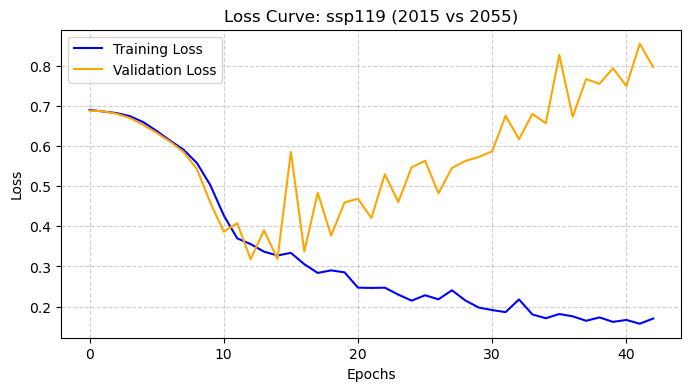

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
--> Iteration Accuracy: 84.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
final accuracy:  84.00%
Processing: ssp119 | Early: 2015 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.5000 - loss: 0.6740 - val_accuracy: 0.5000 - val_loss: 0.6655
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5000 - loss: 0.6550 - val_accuracy: 0.5000 - val_loss: 0.6473
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5000 - loss: 0.6360 - val_accuracy: 0.5000 - val_loss: 0.6356
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.5000 - loss: 0.6175 - val_accuracy: 0.5000 - val_loss: 0.6137
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5100 - loss: 0.5969 - val_accuracy: 0.5000 - val_loss: 0.5946
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5625 - loss: 0.5759 - val_accuracy: 0.5400 - val_loss: 0.5821
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.6900 - loss: 0.5441 - val_accuracy: 0.6800 - val_loss: 0.

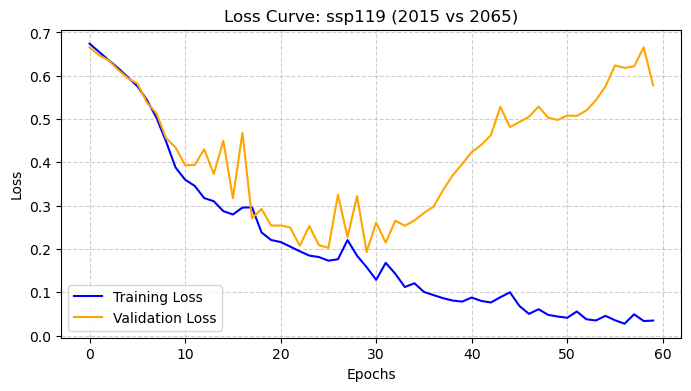

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 389ms/step
--> Iteration Accuracy: 88.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2015 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.5125 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5750 - loss: 0.6898 - val_accuracy: 0.5400 - val_loss: 0.6899
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5850 - loss: 0.6870 - val_accuracy: 0.5400 - val_loss: 0.6877
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5750 - loss: 0.6832 - val_accuracy: 0.5200 - val_loss: 0.6837
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.5450 - loss: 0.6771 - val_accuracy: 0.5200 - val_loss: 0.6770
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5475 - loss: 0.6657 - val_accuracy: 0.5200 - val_loss: 0.6639
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5325 - loss: 0.6486 - val_accuracy: 0.5200 - val_loss: 0.

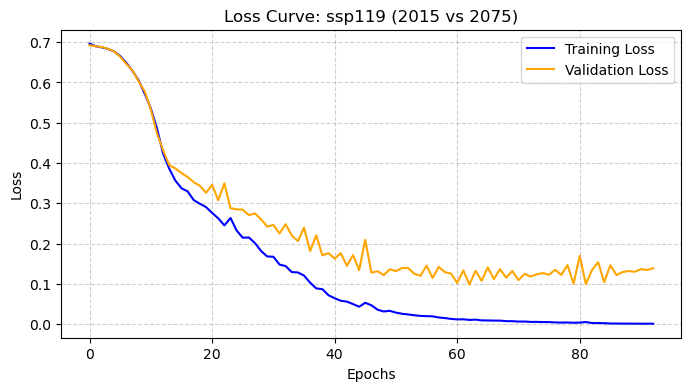

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
--> Iteration Accuracy: 98.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
final accuracy:  98.00%
Processing: ssp119 | Early: 2015 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.4975 - loss: 0.6901 - val_accuracy: 0.5200 - val_loss: 0.6880
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5075 - loss: 0.6864 - val_accuracy: 0.5200 - val_loss: 0.6822
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5050 - loss: 0.6797 - val_accuracy: 0.5000 - val_loss: 0.6738
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.5025 - loss: 0.6702 - val_accuracy: 0.5000 - val_loss: 0.6645
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5025 - loss: 0.6591 - val_accuracy: 0.5000 - val_loss: 0.6501
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5000 - loss: 0.6441 - val_accuracy: 0.5000 - val_loss: 0.6349
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.5000 - loss: 0.6289 - val_accuracy: 0.5000 - val_loss: 0.

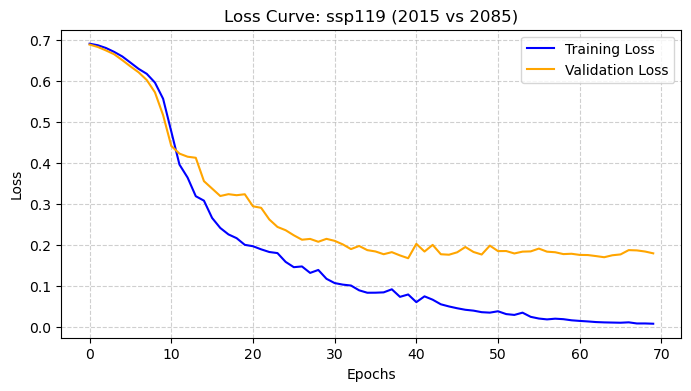

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step
--> Iteration Accuracy: 96.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
final accuracy:  96.00%
Processing: ssp119 | Early: 2025 | Late: 2035
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5025 - loss: 0.6912 - val_accuracy: 0.5200 - val_loss: 0.6928
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5075 - loss: 0.6896 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5100 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5125 - loss: 0.6861 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.5150 - loss: 0.6837 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5150 - loss: 0.6809 - val_accuracy: 0.5000 - val_loss: 0.

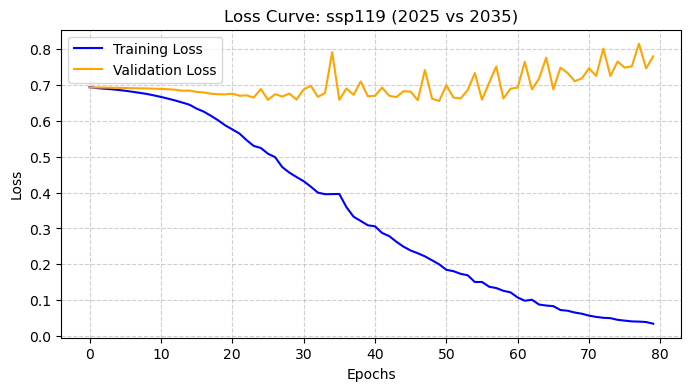

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
--> Iteration Accuracy: 52.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
final accuracy:  52.00%
Processing: ssp119 | Early: 2025 | Late: 2045
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - accuracy: 0.5000 - loss: 0.6967 - val_accuracy: 0.5000 - val_loss: 0.6888
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5050 - loss: 0.6914 - val_accuracy: 0.5400 - val_loss: 0.6836
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5100 - loss: 0.6875 - val_accuracy: 0.5400 - val_loss: 0.6786
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5250 - loss: 0.6823 - val_accuracy: 0.5800 - val_loss: 0.6761
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5225 - loss: 0.6776 - val_accuracy: 0.5800 - val_loss: 0.6741
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5350 - loss: 0.6740 - val_accuracy: 0.5800 - val_loss: 0.6731
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5475 - loss: 0.6713 - val_accuracy: 0.5800 - val_loss: 0.

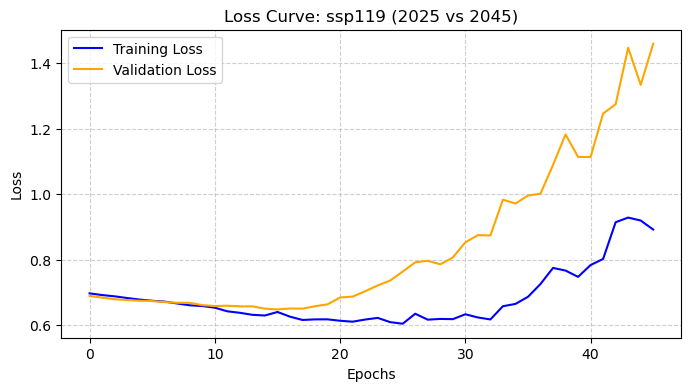

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
--> Iteration Accuracy: 48.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
final accuracy:  48.00%
Processing: ssp119 | Early: 2025 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.4675 - loss: 0.6935 - val_accuracy: 0.5600 - val_loss: 0.6890
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5175 - loss: 0.6903 - val_accuracy: 0.6200 - val_loss: 0.6879
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.5275 - loss: 0.6886 - val_accuracy: 0.6000 - val_loss: 0.6870
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5375 - loss: 0.6869 - val_accuracy: 0.5200 - val_loss: 0.6845
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5575 - loss: 0.6849 - val_accuracy: 0.5400 - val_loss: 0.6825
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.5600 - loss: 0.6827 - val_accuracy: 0.5800 - val_loss: 0.6809
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5925 - loss: 0.6819 - val_accuracy: 0.5600 - val_loss: 0.

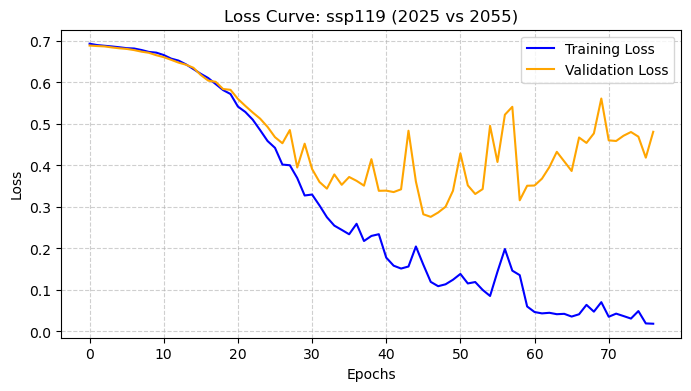

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step
--> Iteration Accuracy: 88.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2025 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.5000 - loss: 0.7058 - val_accuracy: 0.5000 - val_loss: 0.7112
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.5000 - loss: 0.7114 - val_accuracy: 0.5000 - val_loss: 0.7229
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.5000 - loss: 0.7289 - val_accuracy: 0.5000 - val_loss: 0.7547
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5000 - loss: 0.7909 - val_accuracy: 0.5000 - val_loss: 0.8737
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5000 - loss: 0.9961 - val_accuracy: 0.5000 - val_loss: 1.2653
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.5000 - loss: 1.6848 - val_accuracy: 0.5000 - val_loss: 2.3697
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5000 - loss: 3.3097 - val_accuracy: 0.5000 - val_loss: 4.

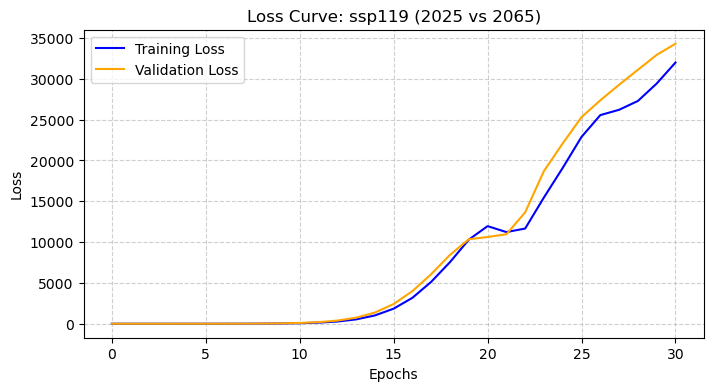

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
--> Iteration Accuracy: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
final accuracy:  50.00%
Processing: ssp119 | Early: 2025 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 249ms/step - accuracy: 0.5025 - loss: 0.6902 - val_accuracy: 0.5000 - val_loss: 0.6895
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5050 - loss: 0.6848 - val_accuracy: 0.5000 - val_loss: 0.6886
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.5025 - loss: 0.6810 - val_accuracy: 0.5000 - val_loss: 0.6861
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5000 - loss: 0.6792 - val_accuracy: 0.5000 - val_loss: 0.6847
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.5000 - loss: 0.6731 - val_accuracy: 0.5000 - val_loss: 0.6785
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.5000 - loss: 0.6674 - val_accuracy: 0.5000 - val_loss: 0.6756
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.5025 - loss: 0.6604 - val_accuracy: 0.5000 - val_loss: 0.

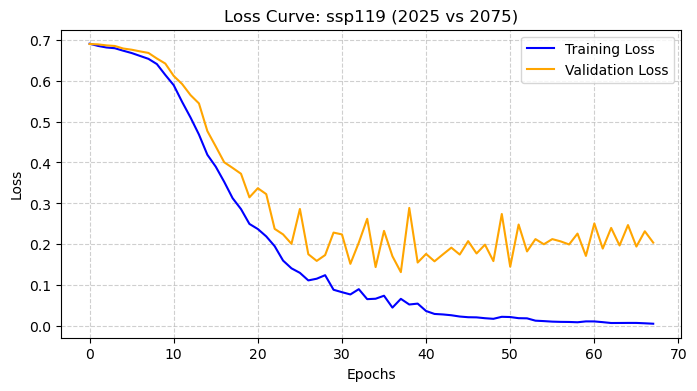

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
--> Iteration Accuracy: 88.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2025 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 264ms/step - accuracy: 0.5000 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.6914
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5000 - loss: 0.6864 - val_accuracy: 0.5000 - val_loss: 0.6893
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5000 - loss: 0.6824 - val_accuracy: 0.5000 - val_loss: 0.6875
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.5000 - loss: 0.6774 - val_accuracy: 0.5000 - val_loss: 0.6846
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5025 - loss: 0.6739 - val_accuracy: 0.5200 - val_loss: 0.6828
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5050 - loss: 0.6677 - val_accuracy: 0.5200 - val_loss: 0.6754
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.5325 - loss: 0.6591 - val_accuracy: 0.5400 - val_loss: 0.

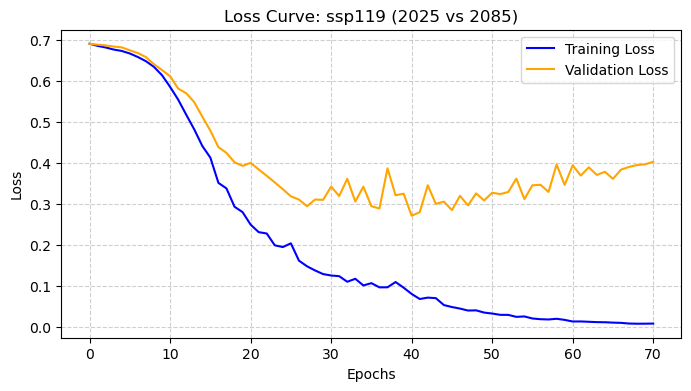

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step
--> Iteration Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
final accuracy:  100.00%
Processing: ssp119 | Early: 2035 | Late: 2045
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.5075 - loss: 0.6953 - val_accuracy: 0.4800 - val_loss: 0.6899
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.5275 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5525 - loss: 0.6915 - val_accuracy: 0.5200 - val_loss: 0.6911
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5550 - loss: 0.6902 - val_accuracy: 0.5600 - val_loss: 0.6910
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5975 - loss: 0.6890 - val_accuracy: 0.5600 - val_loss: 0.6909
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5875 - loss: 0.6879 - val_accuracy: 0.5200 - val_loss: 0.6902
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.6000 - loss: 0.6867 - val_accuracy: 0.4800 - val_loss: 0.

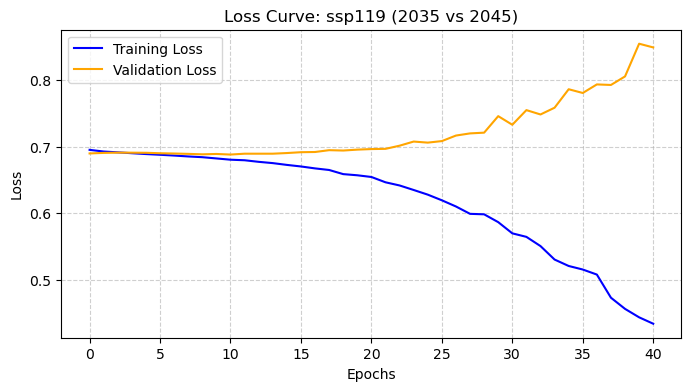

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
--> Iteration Accuracy: 52.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
final accuracy:  52.00%
Processing: ssp119 | Early: 2035 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.5000 - loss: 0.6955 - val_accuracy: 0.5200 - val_loss: 0.6952
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.5000 - loss: 0.6938 - val_accuracy: 0.5200 - val_loss: 0.6944
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5025 - loss: 0.6922 - val_accuracy: 0.5200 - val_loss: 0.6950
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5100 - loss: 0.6914 - val_accuracy: 0.5200 - val_loss: 0.6947
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5225 - loss: 0.6896 - val_accuracy: 0.5400 - val_loss: 0.6929
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5475 - loss: 0.6870 - val_accuracy: 0.5400 - val_loss: 0.6933
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5675 - loss: 0.6860 - val_accuracy: 0.5000 - val_loss: 0.

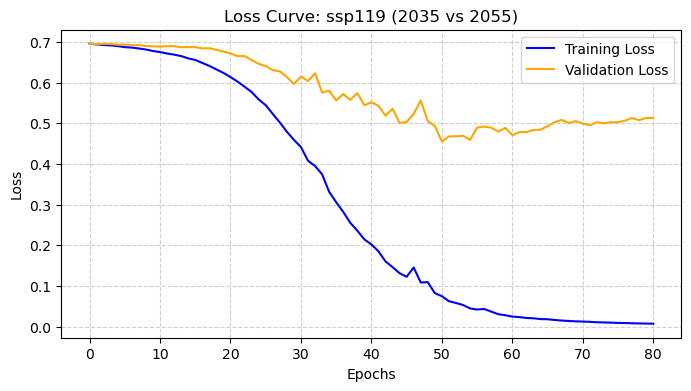

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step
--> Iteration Accuracy: 80.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
final accuracy:  80.00%
Processing: ssp119 | Early: 2035 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 329ms/step - accuracy: 0.5250 - loss: 0.6914 - val_accuracy: 0.5400 - val_loss: 0.6909
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5200 - loss: 0.6897 - val_accuracy: 0.5400 - val_loss: 0.6892
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5350 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6886
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5350 - loss: 0.6875 - val_accuracy: 0.5400 - val_loss: 0.6883
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5500 - loss: 0.6861 - val_accuracy: 0.5400 - val_loss: 0.6881
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5425 - loss: 0.6845 - val_accuracy: 0.5400 - val_loss: 0.6868
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5425 - loss: 0.6831 - val_accuracy: 0.5200 - val_loss: 0.

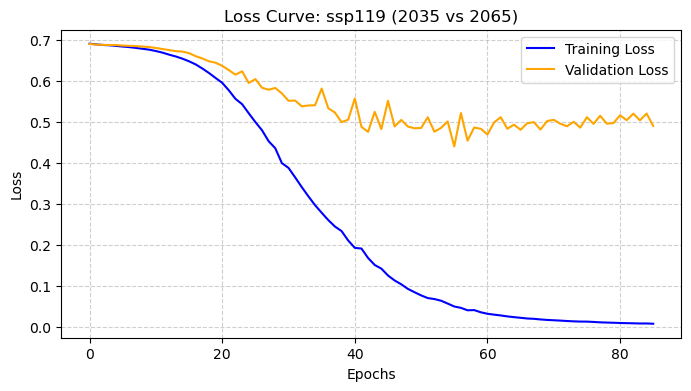

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
--> Iteration Accuracy: 86.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
final accuracy:  86.00%
Processing: ssp119 | Early: 2035 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 193ms/step - accuracy: 0.5000 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6897
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.5000 - loss: 0.6904 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5000 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6890
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5000 - loss: 0.6862 - val_accuracy: 0.5000 - val_loss: 0.6883
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5000 - loss: 0.6843 - val_accuracy: 0.5000 - val_loss: 0.6869
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5000 - loss: 0.6815 - val_accuracy: 0.5000 - val_loss: 0.6854
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5000 - loss: 0.6788 - val_accuracy: 0.5000 - val_loss: 0

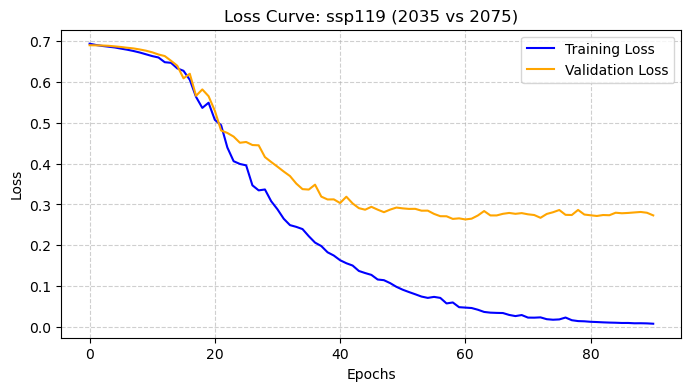

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
--> Iteration Accuracy: 88.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2035 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.5125 - loss: 0.6940 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.5475 - loss: 0.6864 - val_accuracy: 0.5200 - val_loss: 0.6889
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5600 - loss: 0.6829 - val_accuracy: 0.5200 - val_loss: 0.6859
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.6000 - loss: 0.6777 - val_accuracy: 0.5200 - val_loss: 0.6823
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.6375 - loss: 0.6692 - val_accuracy: 0.5400 - val_loss: 0.6740
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.6400 - loss: 0.6600 - val_accuracy: 0.5600 - val_loss: 0.6597
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.6600 - loss: 0.6481 - val_accuracy: 0.6000 - val_loss: 0.

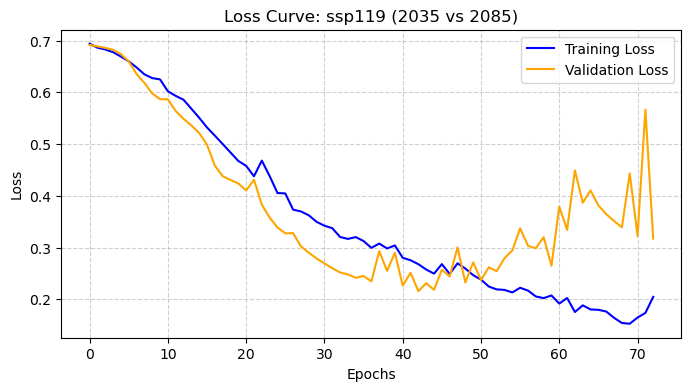

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
--> Iteration Accuracy: 92.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
final accuracy:  92.00%
Processing: ssp119 | Early: 2045 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.5000 - loss: 0.6989 - val_accuracy: 0.5000 - val_loss: 0.6990
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.5000 - loss: 0.6955 - val_accuracy: 0.5000 - val_loss: 0.6991
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5050 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6976
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5075 - loss: 0.6922 - val_accuracy: 0.4800 - val_loss: 0.6970
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5000 - loss: 0.6923 - val_accuracy: 0.4600 - val_loss: 0.6965
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5375 - loss: 0.6911 - val_accuracy: 0.5600 - val_loss: 0.6969
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5725 - loss: 0.6900 - val_accuracy: 0.5600 - val_loss: 0.

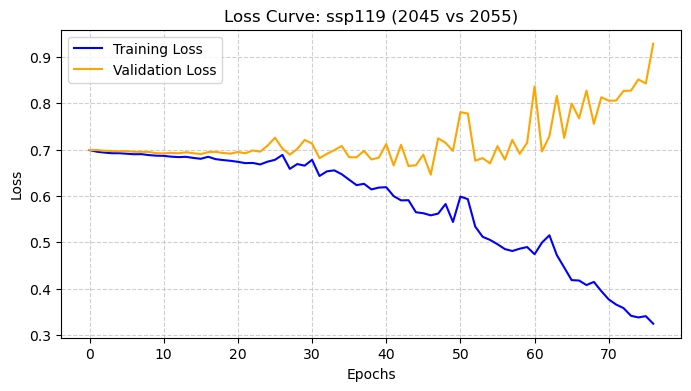

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
--> Iteration Accuracy: 60.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
final accuracy:  60.00%
Processing: ssp119 | Early: 2045 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - accuracy: 0.5000 - loss: 0.7032 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.5000 - loss: 0.6988 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5000 - loss: 0.7015 - val_accuracy: 0.5000 - val_loss: 0.6995
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.5000 - loss: 0.7096 - val_accuracy: 0.5000 - val_loss: 0.7097
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.5000 - loss: 0.7285 - val_accuracy: 0.5000 - val_loss: 0.7404
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5000 - loss: 0.7927 - val_accuracy: 0.5000 - val_loss: 0.8487
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5000 - loss: 0.9655 - val_accuracy: 0.5000 - val_loss: 1.

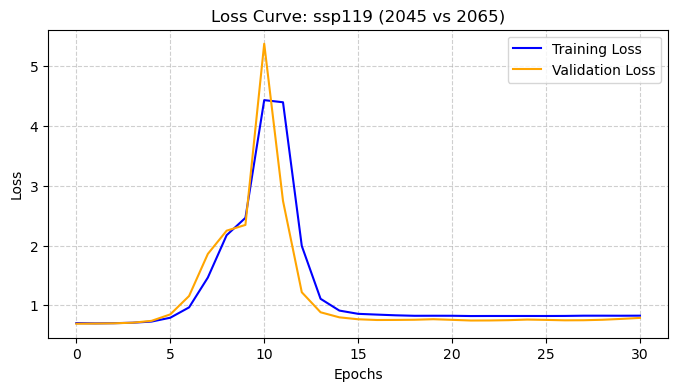

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step
--> Iteration Accuracy: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
final accuracy:  50.00%
Processing: ssp119 | Early: 2045 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.5000 - loss: 0.6953 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5000 - loss: 0.6950 - val_accuracy: 0.5000 - val_loss: 0.6950
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.5000 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.5000 - loss: 0.6957 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.5000 - loss: 0.6962 - val_accuracy: 0.5000 - val_loss: 0.6967
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5000 - loss: 0.6985 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5025 - loss: 0.7012 - val_accuracy: 0.5200 - val_loss: 0.

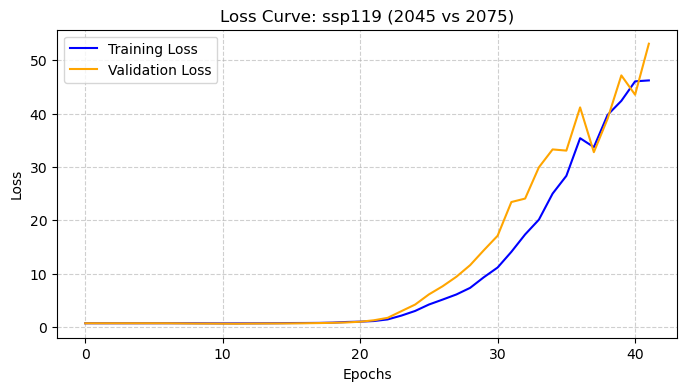

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
--> Iteration Accuracy: 58.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
final accuracy:  58.00%
Processing: ssp119 | Early: 2045 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5025 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5025 - loss: 0.6922 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.5050 - loss: 0.6912 - val_accuracy: 0.5000 - val_loss: 0.6920
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5050 - loss: 0.6896 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5100 - loss: 0.6877 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5050 - loss: 0.6863 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.5025 - loss: 0.6848 - val_accuracy: 0.5000 - val_loss: 0.69

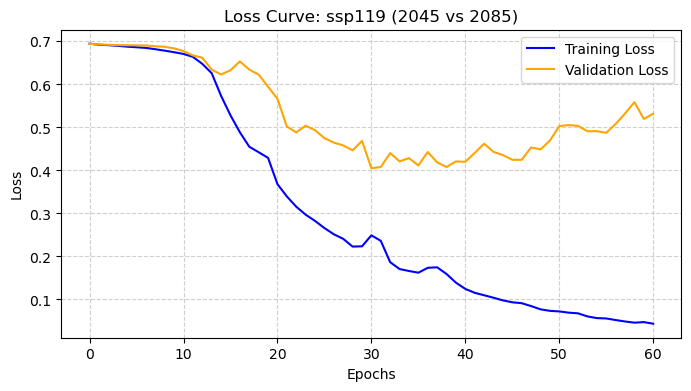

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
--> Iteration Accuracy: 88.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
final accuracy:  88.00%
Processing: ssp119 | Early: 2055 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.5075 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5150 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.5075 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.5025 - loss: 0.6899 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5025 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5100 - loss: 0.6881 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5100 - loss: 0.6868 - val_accuracy: 0.5000 - val_loss: 0.

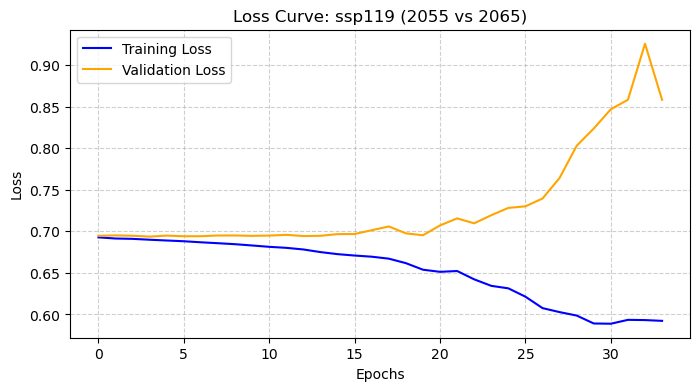

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
--> Iteration Accuracy: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
final accuracy:  50.00%
Processing: ssp119 | Early: 2055 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 331ms/step - accuracy: 0.5600 - loss: 0.6906 - val_accuracy: 0.4200 - val_loss: 0.6935
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.6175 - loss: 0.6854 - val_accuracy: 0.5200 - val_loss: 0.6915
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.6600 - loss: 0.6823 - val_accuracy: 0.4800 - val_loss: 0.6911
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.6675 - loss: 0.6789 - val_accuracy: 0.4800 - val_loss: 0.6914
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.7075 - loss: 0.6757 - val_accuracy: 0.5200 - val_loss: 0.6881
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.7375 - loss: 0.6705 - val_accuracy: 0.5000 - val_loss: 0.6859
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.7275 - loss: 0.6661 - val_accuracy: 0.5000 - val_loss: 0.

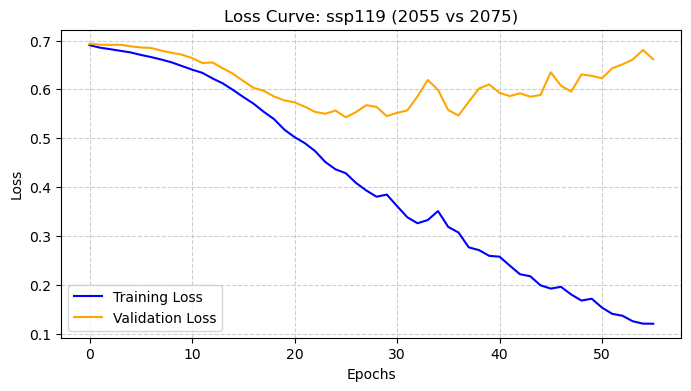

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step
--> Iteration Accuracy: 58.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
final accuracy:  58.00%
Processing: ssp119 | Early: 2055 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.5000 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.6973
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.4975 - loss: 0.6917 - val_accuracy: 0.4800 - val_loss: 0.6969
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.4950 - loss: 0.6894 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5300 - loss: 0.6851 - val_accuracy: 0.5600 - val_loss: 0.6957
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5850 - loss: 0.6823 - val_accuracy: 0.5400 - val_loss: 0.6943
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.6000 - loss: 0.6780 - val_accuracy: 0.5200 - val_loss: 0.6924
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6250 - loss: 0.6738 - val_accuracy: 0.5400 - val_loss: 0.

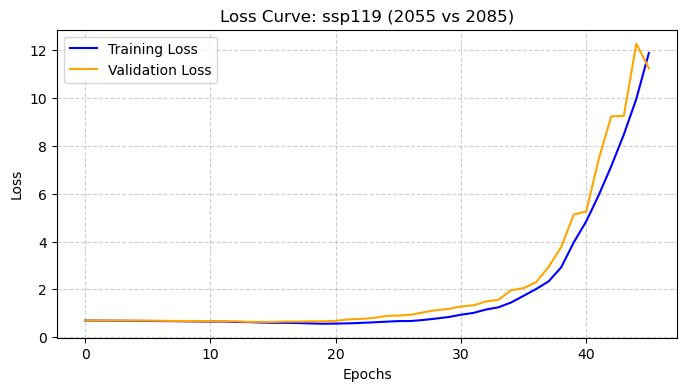

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step
--> Iteration Accuracy: 60.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
final accuracy:  60.00%
Processing: ssp119 | Early: 2065 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.4625 - loss: 0.6956 - val_accuracy: 0.4600 - val_loss: 0.6968
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.5000 - loss: 0.6922 - val_accuracy: 0.4400 - val_loss: 0.6957
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.5225 - loss: 0.6910 - val_accuracy: 0.4200 - val_loss: 0.6959
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5700 - loss: 0.6898 - val_accuracy: 0.4400 - val_loss: 0.6963
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5700 - loss: 0.6884 - val_accuracy: 0.4800 - val_loss: 0.6970
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.6050 - loss: 0.6868 - val_accuracy: 0.4400 - val_loss: 0.6968
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6475 - loss: 0.6851 - val_accuracy: 0.5000 - val_loss: 0.

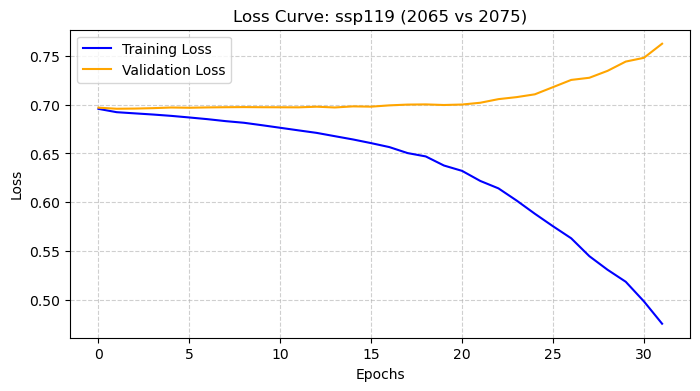

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step
--> Iteration Accuracy: 44.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
final accuracy:  44.00%
Processing: ssp119 | Early: 2065 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.5050 - loss: 0.6964 - val_accuracy: 0.5400 - val_loss: 0.6940
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5300 - loss: 0.6933 - val_accuracy: 0.4800 - val_loss: 0.6931
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.5475 - loss: 0.6915 - val_accuracy: 0.5400 - val_loss: 0.6933
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5425 - loss: 0.6905 - val_accuracy: 0.5200 - val_loss: 0.6930
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5600 - loss: 0.6894 - val_accuracy: 0.5400 - val_loss: 0.6923
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5725 - loss: 0.6881 - val_accuracy: 0.5400 - val_loss: 0.6918
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5875 - loss: 0.6865 - val_accuracy: 0.5400 - val_loss: 0.

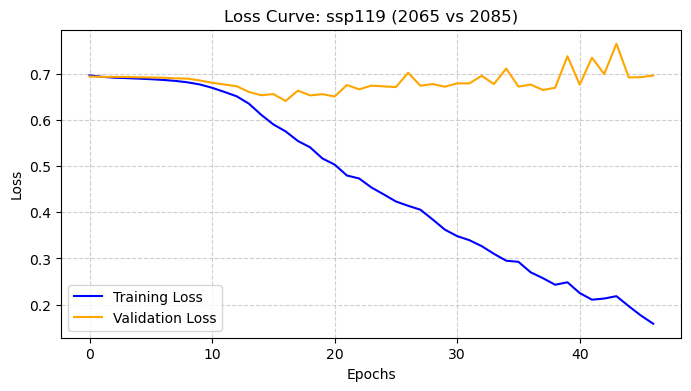

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
--> Iteration Accuracy: 64.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
final accuracy:  64.00%
Processing: ssp119 | Early: 2075 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.5000 - loss: 0.6948 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.5175 - loss: 0.6918 - val_accuracy: 0.4800 - val_loss: 0.6951
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.5200 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5250 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5300 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6938
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5300 - loss: 0.6908 - val_accuracy: 0.5200 - val_loss: 0.6934
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5275 - loss: 0.6908 - val_accuracy: 0.5000 - val_loss: 0.

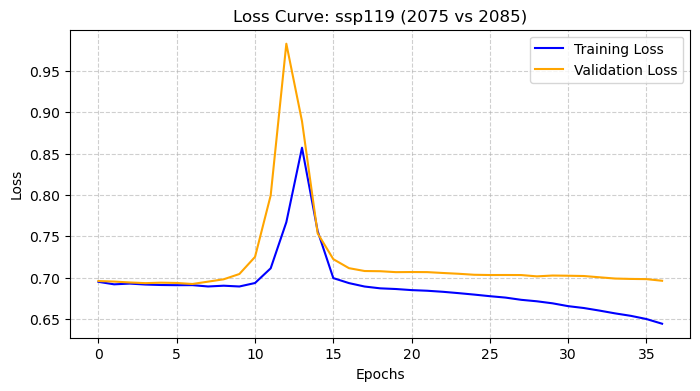

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
--> Iteration Accuracy: 58.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
final accuracy:  58.00%
Processing: ssp126 | Early: 2015 | Late: 2025
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 329ms/step - accuracy: 0.5375 - loss: 0.6918 - val_accuracy: 0.5800 - val_loss: 0.6912
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.6000 - loss: 0.6879 - val_accuracy: 0.6200 - val_loss: 0.6901
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.6100 - loss: 0.6817 - val_accuracy: 0.6000 - val_loss: 0.6822
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5575 - loss: 0.6701 - val_accuracy: 0.5400 - val_loss: 0.6686
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5400 - loss: 0.6532 - val_accuracy: 0.5200 - val_loss: 0.6547
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5600 - loss: 0.6379 - val_accuracy: 0.6000 - val_loss: 0.6450
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.6075 - loss: 0.6213 - val_accuracy: 0.6200 - val_loss: 0

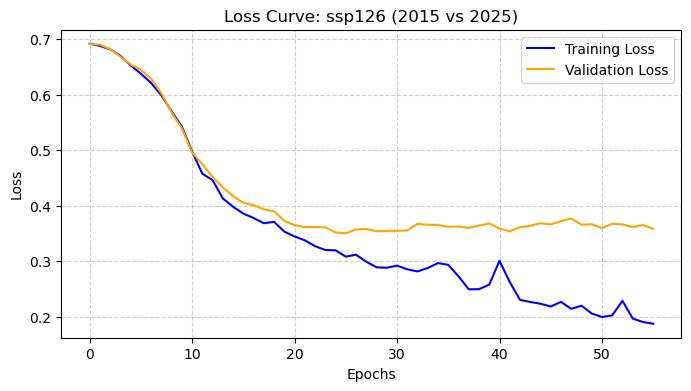

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step
--> Iteration Accuracy: 82.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
final accuracy:  82.00%
Processing: ssp126 | Early: 2015 | Late: 2035
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.4300 - loss: 0.6989 - val_accuracy: 0.6400 - val_loss: 0.6889
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.5825 - loss: 0.6891 - val_accuracy: 0.6800 - val_loss: 0.6817
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.6375 - loss: 0.6775 - val_accuracy: 0.6400 - val_loss: 0.6657
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.6875 - loss: 0.6611 - val_accuracy: 0.7800 - val_loss: 0.6418
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.7600 - loss: 0.6343 - val_accuracy: 0.8200 - val_loss: 0.6048
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.8200 - loss: 0.5864 - val_accuracy: 0.8600 - val_loss: 0.5307
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.8500 - loss: 0.5081 - val_accuracy: 0.8400 - val_loss: 0.

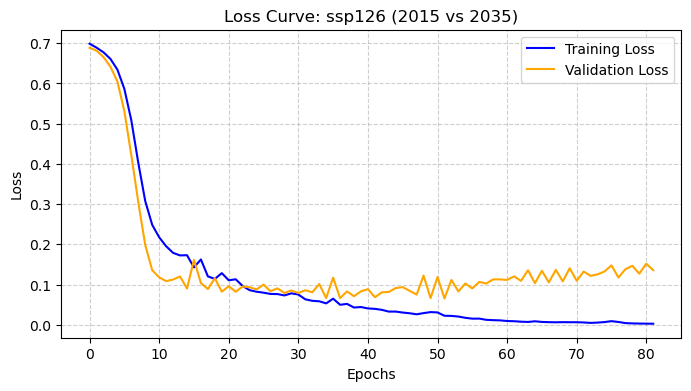

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
--> Iteration Accuracy: 92.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
final accuracy:  92.00%
Processing: ssp126 | Early: 2015 | Late: 2045
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 358ms/step - accuracy: 0.4900 - loss: 0.6919 - val_accuracy: 0.4800 - val_loss: 0.6787
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5175 - loss: 0.6793 - val_accuracy: 0.5000 - val_loss: 0.6600
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.5050 - loss: 0.6545 - val_accuracy: 0.5000 - val_loss: 0.6252
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.5025 - loss: 0.6253 - val_accuracy: 0.5000 - val_loss: 0.5925
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5075 - loss: 0.5959 - val_accuracy: 0.5200 - val_loss: 0.5629
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.5575 - loss: 0.5572 - val_accuracy: 0.6200 - val_loss: 0.5167
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.6700 - loss: 0.5076 - val_accuracy: 0.8000 - val_loss: 0.

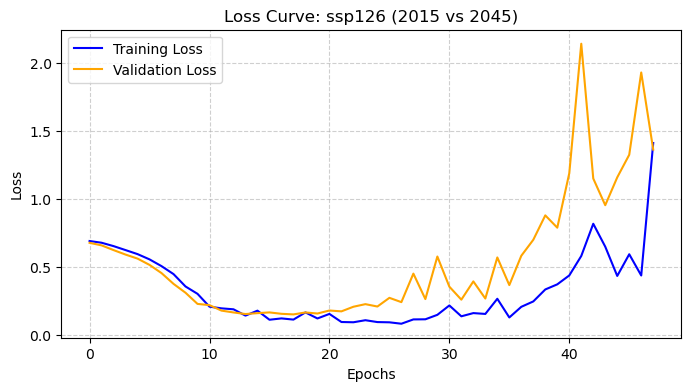

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
--> Iteration Accuracy: 96.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
final accuracy:  96.00%
Processing: ssp126 | Early: 2015 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 328ms/step - accuracy: 0.4975 - loss: 0.6857 - val_accuracy: 0.5000 - val_loss: 0.6649
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5000 - loss: 0.6537 - val_accuracy: 0.5000 - val_loss: 0.6247
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5025 - loss: 0.6166 - val_accuracy: 0.5000 - val_loss: 0.5815
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5025 - loss: 0.5760 - val_accuracy: 0.5000 - val_loss: 0.5376
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5475 - loss: 0.5357 - val_accuracy: 0.6600 - val_loss: 0.4946
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.6025 - loss: 0.4935 - val_accuracy: 0.7200 - val_loss: 0.4480
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.7300 - loss: 0.4490 - val_accuracy: 0.8400 - val_loss: 0.

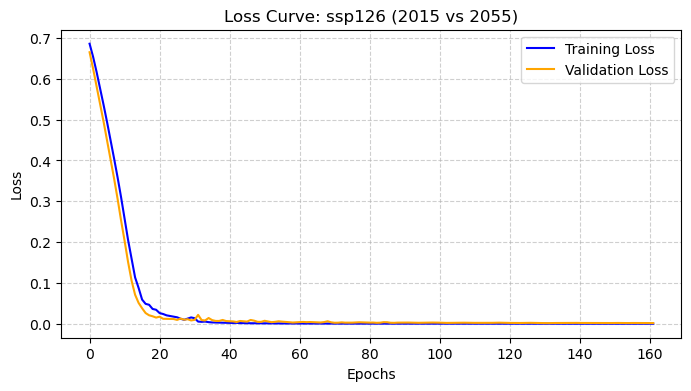

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
--> Iteration Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
final accuracy:  100.00%
Processing: ssp126 | Early: 2015 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.5050 - loss: 0.6878 - val_accuracy: 0.5000 - val_loss: 0.6826
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5050 - loss: 0.6790 - val_accuracy: 0.5200 - val_loss: 0.6729
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5050 - loss: 0.6679 - val_accuracy: 0.5000 - val_loss: 0.6605
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.5050 - loss: 0.6578 - val_accuracy: 0.5000 - val_loss: 0.6504
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5050 - loss: 0.6433 - val_accuracy: 0.5000 - val_loss: 0.6341
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5250 - loss: 0.6168 - val_accuracy: 0.6000 - val_loss: 0.6017
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.6025 - loss: 0.5687 - val_accuracy: 0.6400 - val_loss: 0.

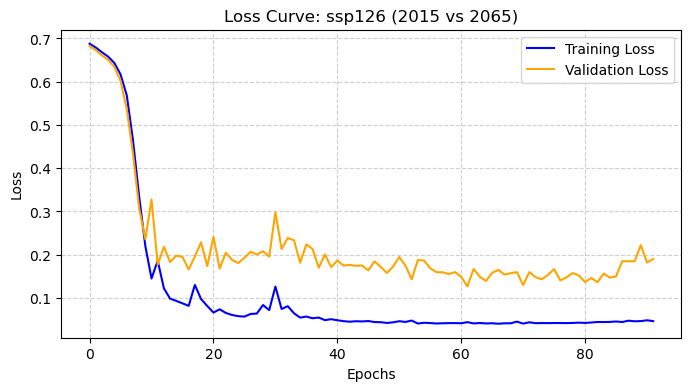

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
--> Iteration Accuracy: 96.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
final accuracy:  96.00%
Processing: ssp126 | Early: 2015 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 471ms/step - accuracy: 0.4675 - loss: 0.6906 - val_accuracy: 0.5600 - val_loss: 0.6850
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5650 - loss: 0.6752 - val_accuracy: 0.5600 - val_loss: 0.6619
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.6125 - loss: 0.6449 - val_accuracy: 0.5200 - val_loss: 0.6348
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.6025 - loss: 0.6087 - val_accuracy: 0.5200 - val_loss: 0.6015
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.6125 - loss: 0.5635 - val_accuracy: 0.5200 - val_loss: 0.5661
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.6825 - loss: 0.5207 - val_accuracy: 0.6600 - val_loss: 0.5241
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.7925 - loss: 0.4732 - val_accuracy: 0.7600 - val_loss: 0.

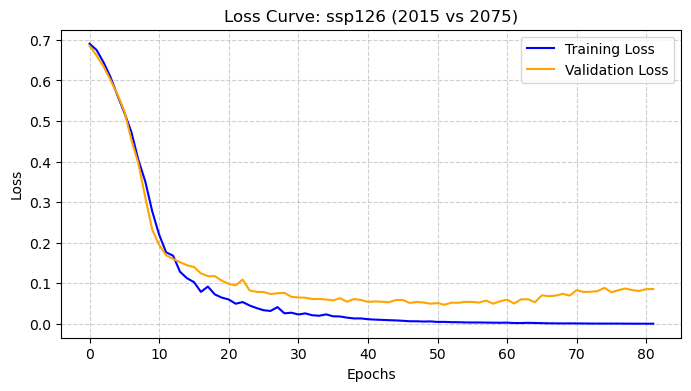

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 489ms/step
--> Iteration Accuracy: 98.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
final accuracy:  98.00%
Processing: ssp126 | Early: 2015 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.5075 - loss: 0.6928 - val_accuracy: 0.6400 - val_loss: 0.6784
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.5650 - loss: 0.6676 - val_accuracy: 0.5800 - val_loss: 0.6496
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5225 - loss: 0.6379 - val_accuracy: 0.5000 - val_loss: 0.6166
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.5125 - loss: 0.6062 - val_accuracy: 0.5200 - val_loss: 0.5879
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.5275 - loss: 0.5754 - val_accuracy: 0.5400 - val_loss: 0.5630
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5675 - loss: 0.5411 - val_accuracy: 0.6800 - val_loss: 0.5259
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6825 - loss: 0.4965 - val_accuracy: 0.8000 - val_loss: 0.

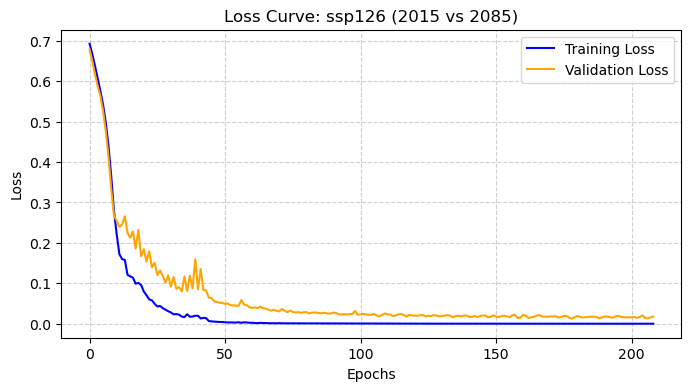

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
--> Iteration Accuracy: 98.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
final accuracy:  98.00%
Processing: ssp126 | Early: 2025 | Late: 2035
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.5175 - loss: 0.6914 - val_accuracy: 0.4600 - val_loss: 0.6920
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.6275 - loss: 0.6859 - val_accuracy: 0.5400 - val_loss: 0.6892
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.5450 - loss: 0.6822 - val_accuracy: 0.5200 - val_loss: 0.6864
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.5300 - loss: 0.6736 - val_accuracy: 0.5200 - val_loss: 0.6853
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5625 - loss: 0.6664 - val_accuracy: 0.5600 - val_loss: 0.6840
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5775 - loss: 0.6573 - val_accuracy: 0.5800 - val_loss: 0.6840
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.6150 - loss: 0.6470 - val_accuracy: 0.5600 - val_loss: 0.

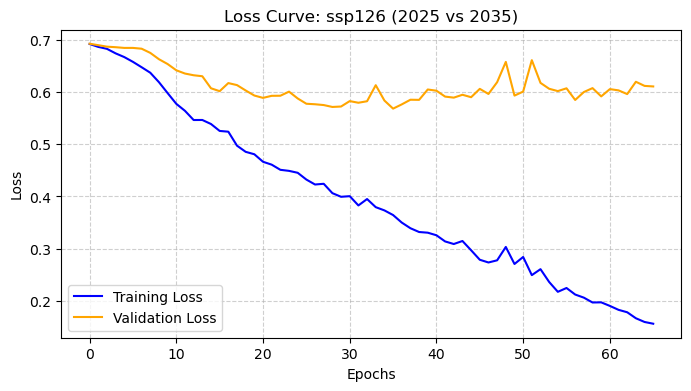

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
--> Iteration Accuracy: 78.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
final accuracy:  78.00%
Processing: ssp126 | Early: 2025 | Late: 2045
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 439ms/step - accuracy: 0.5225 - loss: 0.6928 - val_accuracy: 0.5600 - val_loss: 0.6798
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5875 - loss: 0.6769 - val_accuracy: 0.6200 - val_loss: 0.6736
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.6625 - loss: 0.6675 - val_accuracy: 0.6600 - val_loss: 0.6655
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6575 - loss: 0.6554 - val_accuracy: 0.6000 - val_loss: 0.6518
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.6800 - loss: 0.6403 - val_accuracy: 0.6600 - val_loss: 0.6428
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.6925 - loss: 0.6236 - val_accuracy: 0.7000 - val_loss: 0.6217
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.7225 - loss: 0.5975 - val_accuracy: 0.7200 - val_loss: 0

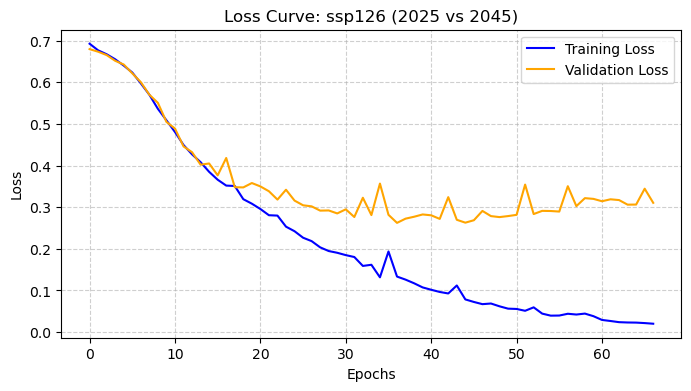

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step
--> Iteration Accuracy: 82.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
final accuracy:  82.00%
Processing: ssp126 | Early: 2025 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 0.4975 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6902
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5625 - loss: 0.6880 - val_accuracy: 0.4600 - val_loss: 0.6860
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5850 - loss: 0.6791 - val_accuracy: 0.5400 - val_loss: 0.6764
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5475 - loss: 0.6686 - val_accuracy: 0.5600 - val_loss: 0.6671
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5375 - loss: 0.6590 - val_accuracy: 0.5400 - val_loss: 0.6554
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.5300 - loss: 0.6507 - val_accuracy: 0.5400 - val_loss: 0.6504
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5350 - loss: 0.6401 - val_accuracy: 0.6000 - val_loss: 0.

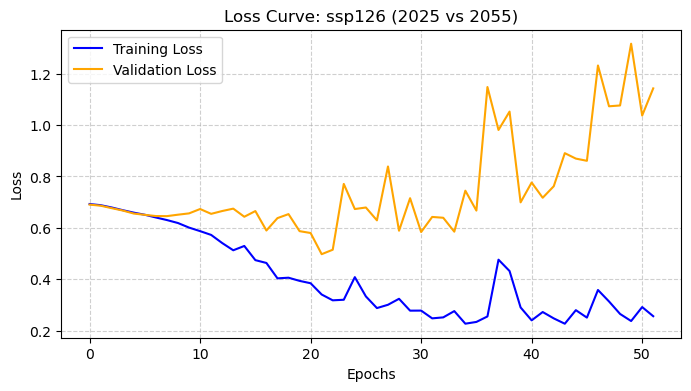

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
--> Iteration Accuracy: 84.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
final accuracy:  84.00%
Processing: ssp126 | Early: 2025 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 224ms/step - accuracy: 0.4875 - loss: 0.7023 - val_accuracy: 0.5400 - val_loss: 0.6927
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5625 - loss: 0.6905 - val_accuracy: 0.5800 - val_loss: 0.6855
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.6400 - loss: 0.6786 - val_accuracy: 0.5200 - val_loss: 0.6788
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.6400 - loss: 0.6694 - val_accuracy: 0.5400 - val_loss: 0.6719
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.6325 - loss: 0.6558 - val_accuracy: 0.5600 - val_loss: 0.6618
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.6450 - loss: 0.6407 - val_accuracy: 0.5400 - val_loss: 0.6511
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.6700 - loss: 0.6184 - val_accuracy: 0.6200 - val_loss: 0.

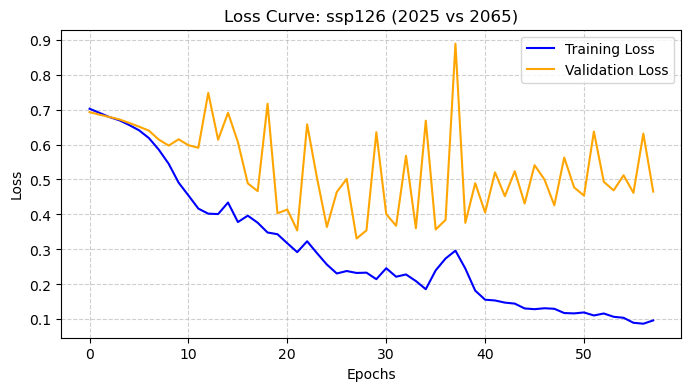

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
--> Iteration Accuracy: 92.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
final accuracy:  92.00%
Processing: ssp126 | Early: 2025 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 378ms/step - accuracy: 0.5025 - loss: 0.7065 - val_accuracy: 0.4800 - val_loss: 0.7015
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.4650 - loss: 0.6989 - val_accuracy: 0.4800 - val_loss: 0.6937
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5250 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6833
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5375 - loss: 0.6763 - val_accuracy: 0.5000 - val_loss: 0.6735
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.5350 - loss: 0.6739 - val_accuracy: 0.4600 - val_loss: 0.6737
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.5650 - loss: 0.6704 - val_accuracy: 0.5600 - val_loss: 0.6656
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.5825 - loss: 0.6601 - val_accuracy: 0.5400 - val_loss: 0.

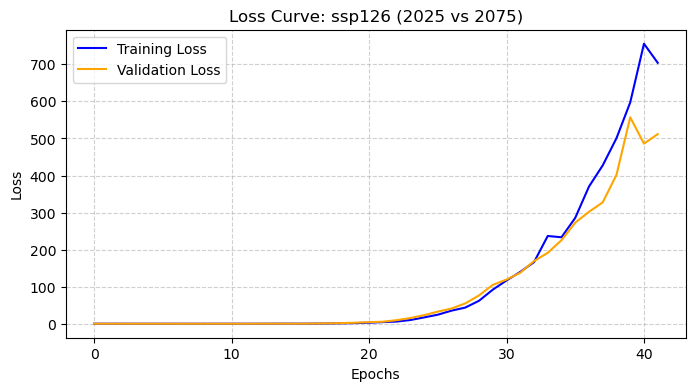

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step
--> Iteration Accuracy: 66.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
final accuracy:  66.00%
Processing: ssp126 | Early: 2025 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - accuracy: 0.5675 - loss: 0.6968 - val_accuracy: 0.5400 - val_loss: 0.7164
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.6025 - loss: 0.6703 - val_accuracy: 0.5000 - val_loss: 0.6809
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5525 - loss: 0.6539 - val_accuracy: 0.5000 - val_loss: 0.6837
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5625 - loss: 0.6459 - val_accuracy: 0.4800 - val_loss: 0.6726
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.6050 - loss: 0.6210 - val_accuracy: 0.6200 - val_loss: 0.6600
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6625 - loss: 0.6056 - val_accuracy: 0.5800 - val_loss: 0.6893
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.7025 - loss: 0.6005 - val_accuracy: 0.6000 - val_loss: 0.

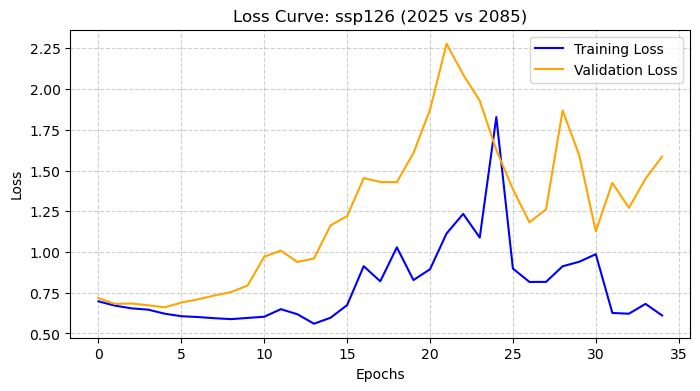

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
--> Iteration Accuracy: 68.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
final accuracy:  68.00%
Processing: ssp126 | Early: 2035 | Late: 2045
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.5000 - loss: 0.6991 - val_accuracy: 0.5000 - val_loss: 0.6981
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.4975 - loss: 0.6956 - val_accuracy: 0.5000 - val_loss: 0.6964
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6958
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.5050 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6963
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5075 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5075 - loss: 0.6895 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.5075 - loss: 0.6892 - val_accuracy: 0.5000 - val_loss: 0.

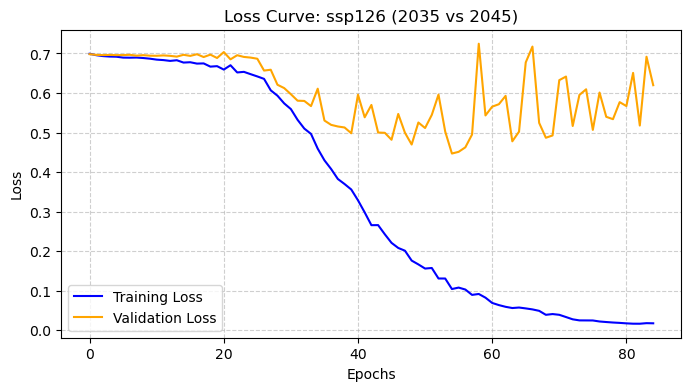

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 404ms/step
--> Iteration Accuracy: 76.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
final accuracy:  76.00%
Processing: ssp126 | Early: 2035 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.5000 - loss: 0.7021 - val_accuracy: 0.5000 - val_loss: 0.7020
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5000 - loss: 0.7159 - val_accuracy: 0.5000 - val_loss: 0.7274
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5000 - loss: 0.7587 - val_accuracy: 0.5000 - val_loss: 0.8065
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5000 - loss: 0.8938 - val_accuracy: 0.5000 - val_loss: 1.0814
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5000 - loss: 1.3421 - val_accuracy: 0.5000 - val_loss: 1.7104
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5000 - loss: 2.1250 - val_accuracy: 0.5000 - val_loss: 2.6186
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.4975 - loss: 2.9512 - val_accuracy: 0.4400 - val_loss: 2.

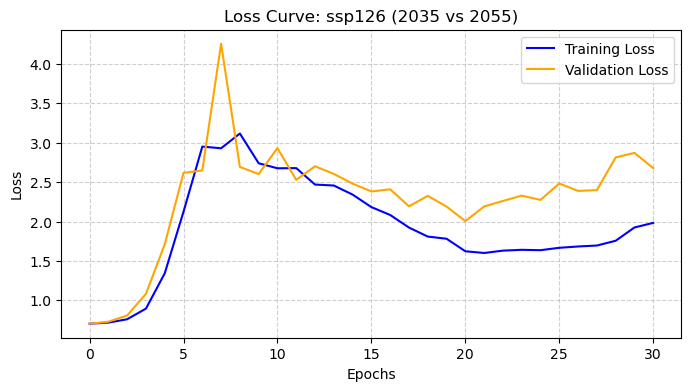

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step
--> Iteration Accuracy: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
final accuracy:  50.00%
Processing: ssp126 | Early: 2035 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 0.5350 - loss: 0.6929 - val_accuracy: 0.5200 - val_loss: 0.6935
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.5475 - loss: 0.6857 - val_accuracy: 0.5000 - val_loss: 0.6910
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5175 - loss: 0.6824 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.5100 - loss: 0.6776 - val_accuracy: 0.5000 - val_loss: 0.6886
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.5150 - loss: 0.6739 - val_accuracy: 0.5000 - val_loss: 0.6859
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.5275 - loss: 0.6689 - val_accuracy: 0.5200 - val_loss: 0.6828
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.5375 - loss: 0.6635 - val_accuracy: 0.5200 - val_loss: 0.

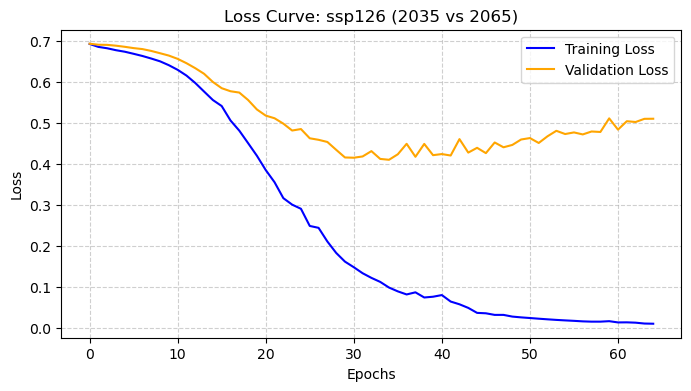

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
--> Iteration Accuracy: 80.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
final accuracy:  80.00%
Processing: ssp126 | Early: 2035 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 442ms/step - accuracy: 0.5075 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.6910
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5075 - loss: 0.6867 - val_accuracy: 0.5000 - val_loss: 0.6883
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.5050 - loss: 0.6851 - val_accuracy: 0.5000 - val_loss: 0.6891
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5075 - loss: 0.6826 - val_accuracy: 0.5200 - val_loss: 0.6868
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.5075 - loss: 0.6799 - val_accuracy: 0.5600 - val_loss: 0.6846
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.5575 - loss: 0.6747 - val_accuracy: 0.5800 - val_loss: 0.6819
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.5525 - loss: 0.6703 - val_accuracy: 0.5600 - val_loss: 0.

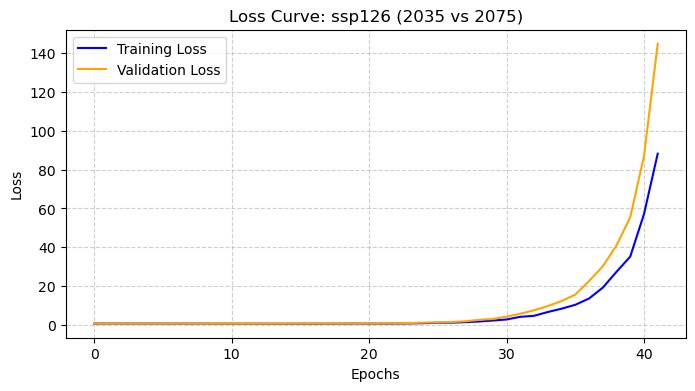

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
--> Iteration Accuracy: 66.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
final accuracy:  66.00%
Processing: ssp126 | Early: 2035 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 372ms/step - accuracy: 0.5375 - loss: 0.6880 - val_accuracy: 0.6200 - val_loss: 0.6718
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5400 - loss: 0.6802 - val_accuracy: 0.6000 - val_loss: 0.6657
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5450 - loss: 0.6745 - val_accuracy: 0.5800 - val_loss: 0.6573
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5750 - loss: 0.6669 - val_accuracy: 0.6400 - val_loss: 0.6482
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.6225 - loss: 0.6568 - val_accuracy: 0.6600 - val_loss: 0.6340
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.6550 - loss: 0.6419 - val_accuracy: 0.7400 - val_loss: 0.6157
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.6850 - loss: 0.6216 - val_accuracy: 0.7600 - val_loss: 0

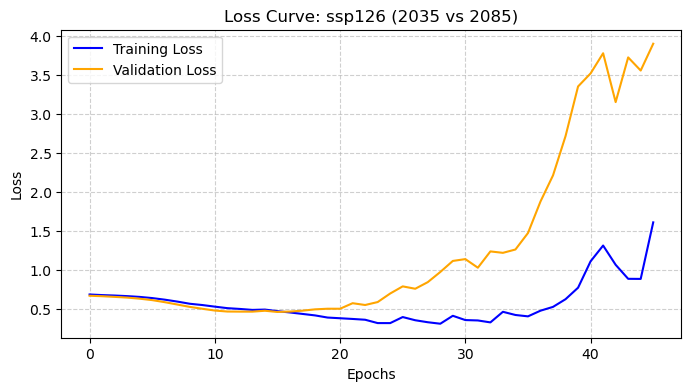

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
--> Iteration Accuracy: 68.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
final accuracy:  68.00%
Processing: ssp126 | Early: 2045 | Late: 2055
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step - accuracy: 0.5200 - loss: 0.6934 - val_accuracy: 0.5400 - val_loss: 0.6933
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5450 - loss: 0.6926 - val_accuracy: 0.4800 - val_loss: 0.6930
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.5325 - loss: 0.6919 - val_accuracy: 0.5200 - val_loss: 0.6933
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5675 - loss: 0.6910 - val_accuracy: 0.4400 - val_loss: 0.6933
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.5725 - loss: 0.6903 - val_accuracy: 0.4600 - val_loss: 0.6929
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.5875 - loss: 0.6900 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5600 - loss: 0.6886 - val_accuracy: 0.4800 - val_loss: 0.

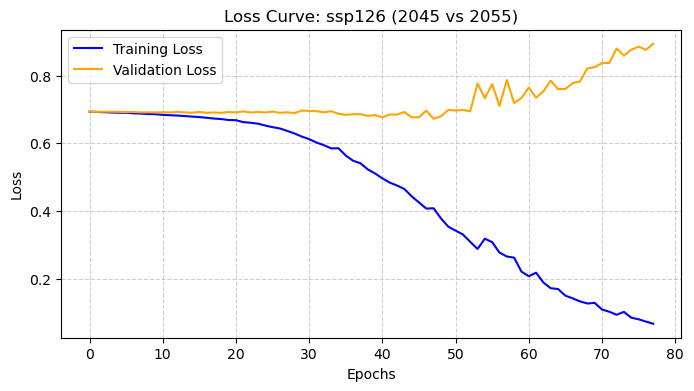

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
--> Iteration Accuracy: 64.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
final accuracy:  64.00%
Processing: ssp126 | Early: 2045 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 456ms/step - accuracy: 0.4800 - loss: 0.6978 - val_accuracy: 0.5000 - val_loss: 0.6978
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5025 - loss: 0.6924 - val_accuracy: 0.4800 - val_loss: 0.6961
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.5375 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.5475 - loss: 0.6898 - val_accuracy: 0.4600 - val_loss: 0.6945
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5925 - loss: 0.6885 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5725 - loss: 0.6872 - val_accuracy: 0.4800 - val_loss: 0.6929
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5800 - loss: 0.6853 - val_accuracy: 0.5000 - val_loss: 0.

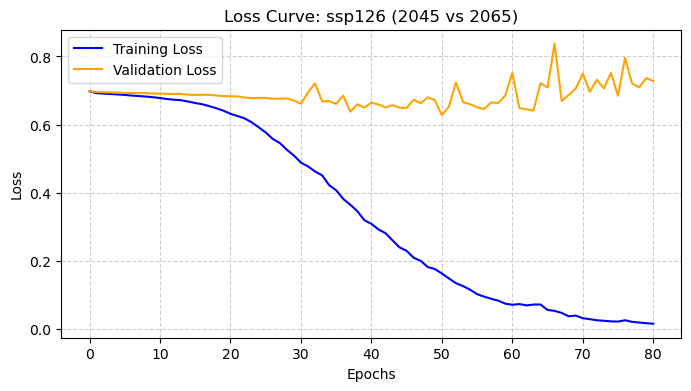

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 716ms/step
--> Iteration Accuracy: 70.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
final accuracy:  70.00%
Processing: ssp126 | Early: 2045 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 372ms/step - accuracy: 0.5000 - loss: 0.6987 - val_accuracy: 0.5000 - val_loss: 0.6969
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.5025 - loss: 0.6935 - val_accuracy: 0.5400 - val_loss: 0.6928
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5050 - loss: 0.6924 - val_accuracy: 0.5200 - val_loss: 0.6935
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.5075 - loss: 0.6904 - val_accuracy: 0.5600 - val_loss: 0.6906
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5775 - loss: 0.6872 - val_accuracy: 0.5800 - val_loss: 0.6860
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.6025 - loss: 0.6850 - val_accuracy: 0.5800 - val_loss: 0.6833
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.6175 - loss: 0.6816 - val_accuracy: 0.5600 - val_loss: 0.

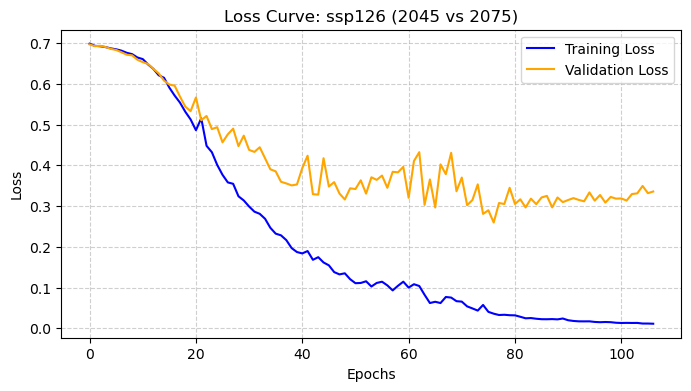

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
--> Iteration Accuracy: 80.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
final accuracy:  80.00%
Processing: ssp126 | Early: 2045 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.4975 - loss: 0.6999 - val_accuracy: 0.4800 - val_loss: 0.7050
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.4925 - loss: 0.6973 - val_accuracy: 0.4600 - val_loss: 0.7043
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.4900 - loss: 0.6968 - val_accuracy: 0.4400 - val_loss: 0.7058
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.4925 - loss: 0.6962 - val_accuracy: 0.4400 - val_loss: 0.7057
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.4900 - loss: 0.6970 - val_accuracy: 0.4400 - val_loss: 0.7061
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5050 - loss: 0.6951 - val_accuracy: 0.4200 - val_loss: 0.7046
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5025 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.

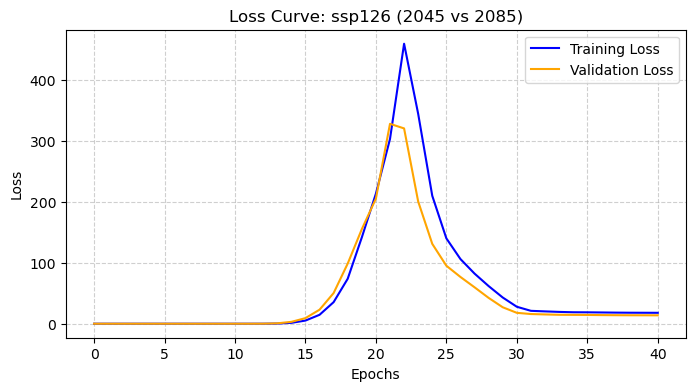

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
--> Iteration Accuracy: 50.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
final accuracy:  50.00%
Processing: ssp126 | Early: 2055 | Late: 2065
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 489ms/step - accuracy: 0.5175 - loss: 0.6929 - val_accuracy: 0.4000 - val_loss: 0.6958
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.5425 - loss: 0.6903 - val_accuracy: 0.4400 - val_loss: 0.6945
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.5425 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.5425 - loss: 0.6872 - val_accuracy: 0.5400 - val_loss: 0.6936
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.5225 - loss: 0.6858 - val_accuracy: 0.5200 - val_loss: 0.6936
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5225 - loss: 0.6842 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5300 - loss: 0.6825 - val_accuracy: 0.5000 - val_loss: 0.

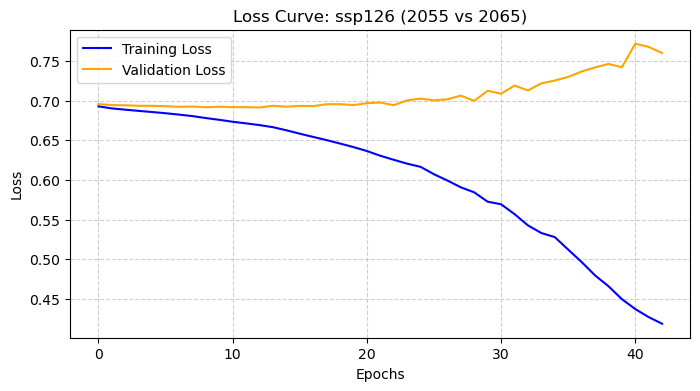

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step
--> Iteration Accuracy: 54.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
final accuracy:  54.00%
Processing: ssp126 | Early: 2055 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - accuracy: 0.4975 - loss: 0.7048 - val_accuracy: 0.4800 - val_loss: 0.7046
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.4900 - loss: 0.7004 - val_accuracy: 0.4600 - val_loss: 0.7029
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.5000 - loss: 0.6969 - val_accuracy: 0.4400 - val_loss: 0.7023
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.4975 - loss: 0.6954 - val_accuracy: 0.4400 - val_loss: 0.7031
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.4975 - loss: 0.6943 - val_accuracy: 0.4400 - val_loss: 0.7046
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.5375 - loss: 0.6918 - val_accuracy: 0.4400 - val_loss: 0.7042
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.5200 - loss: 0.6910 - val_accuracy: 0.4800 - val_loss: 0.

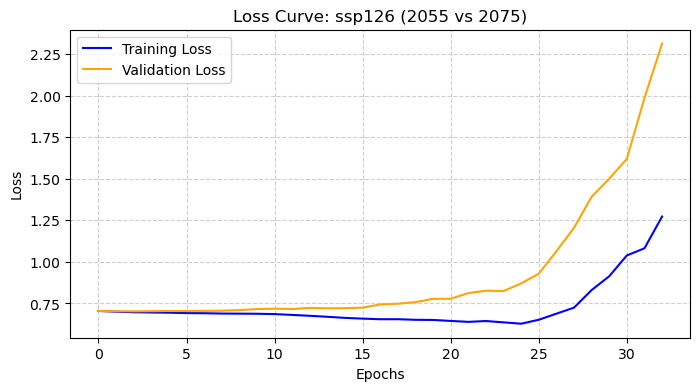

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
--> Iteration Accuracy: 38.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
final accuracy:  38.00%
Processing: ssp126 | Early: 2055 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - accuracy: 0.4775 - loss: 0.6938 - val_accuracy: 0.5200 - val_loss: 0.6933
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.5150 - loss: 0.6914 - val_accuracy: 0.5400 - val_loss: 0.6923
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5700 - loss: 0.6899 - val_accuracy: 0.5200 - val_loss: 0.6911
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.5875 - loss: 0.6887 - val_accuracy: 0.5200 - val_loss: 0.6902
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - accuracy: 0.6100 - loss: 0.6864 - val_accuracy: 0.5600 - val_loss: 0.6894
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.6275 - loss: 0.6839 - val_accuracy: 0.6200 - val_loss: 0.6885
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.6575 - loss: 0.6810 - val_accuracy: 0.6000 - val_loss: 0.

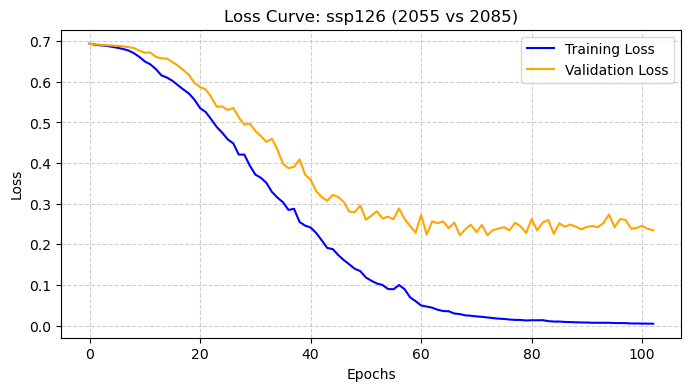

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 477ms/step
--> Iteration Accuracy: 74.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
final accuracy:  74.00%
Processing: ssp126 | Early: 2065 | Late: 2075
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.4900 - loss: 0.6969 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5075 - loss: 0.6933 - val_accuracy: 0.5600 - val_loss: 0.6934
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5450 - loss: 0.6914 - val_accuracy: 0.4600 - val_loss: 0.6934
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.5250 - loss: 0.6916 - val_accuracy: 0.4600 - val_loss: 0.6954
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.5400 - loss: 0.6893 - val_accuracy: 0.4800 - val_loss: 0.6935
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5550 - loss: 0.6878 - val_accuracy: 0.5200 - val_loss: 0.6919
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.5675 - loss: 0.6864 - val_accuracy: 0.4200 - val_loss: 0.

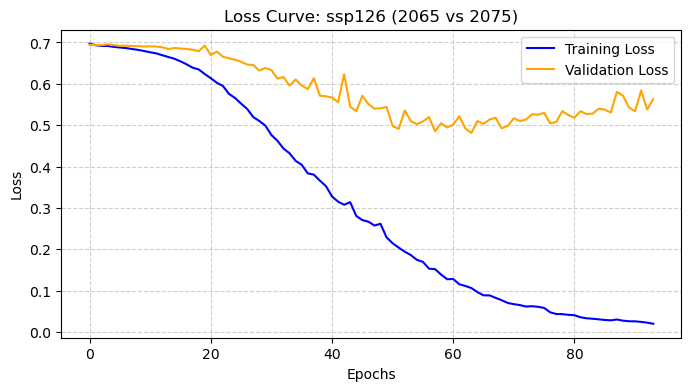

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
--> Iteration Accuracy: 82.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
final accuracy:  82.00%
Processing: ssp126 | Early: 2065 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 389ms/step - accuracy: 0.4750 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.6985
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.5100 - loss: 0.6917 - val_accuracy: 0.4800 - val_loss: 0.6967
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.4975 - loss: 0.6904 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5300 - loss: 0.6877 - val_accuracy: 0.5400 - val_loss: 0.6944
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5625 - loss: 0.6853 - val_accuracy: 0.5200 - val_loss: 0.6934
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.5750 - loss: 0.6831 - val_accuracy: 0.5600 - val_loss: 0.6930
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5600 - loss: 0.6804 - val_accuracy: 0.5800 - val_loss: 0.

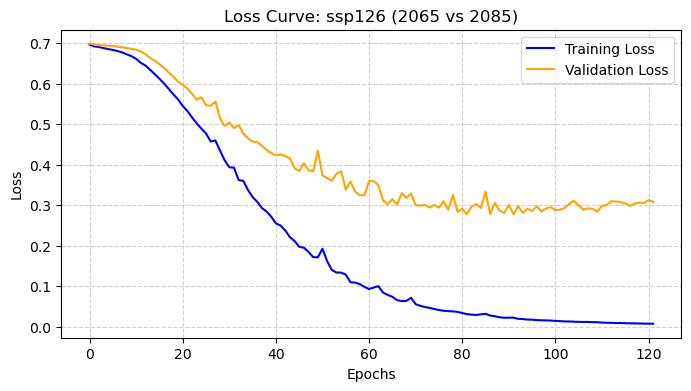

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
--> Iteration Accuracy: 84.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
final accuracy:  84.00%
Processing: ssp126 | Early: 2075 | Late: 2085
processing model: CNRM_ESM2-1


/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:103: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1), dtype = np.float64)  # (144, 73) -- one global map per variable and model
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:114: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)), dtype = np.float64)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_65386/925162584.py:151: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
processing model: MPI-ESM1-2-LR
processing model: MRI-ESM2-0
processing model: UKESM1-0-LL
Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 463ms/step - accuracy: 0.4925 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.5600 - loss: 0.6892 - val_accuracy: 0.4800 - val_loss: 0.6912
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5900 - loss: 0.6876 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.6075 - loss: 0.6851 - val_accuracy: 0.4800 - val_loss: 0.6915
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.6425 - loss: 0.6824 - val_accuracy: 0.4600 - val_loss: 0.6908
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.6650 - loss: 0.6795 - val_accuracy: 0.4800 - val_loss: 0.6903
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.6625 - loss: 0.6777 - val_accuracy: 0.4600 - val_loss: 0.

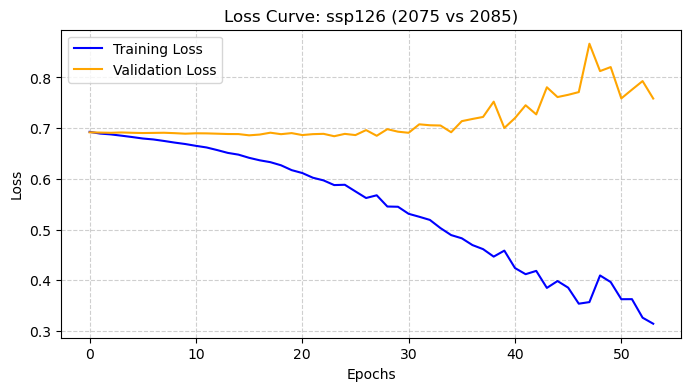

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
--> Iteration Accuracy: 52.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
final accuracy:  52.00%
DONE!


In [11]:
results = run_climate_experiment(['ssp119', 'ssp126'], [2015, 2025, 2035, 2045, 2055, 2065, 2075], model_list, data_path) # Skip 2085, too late (cannot compare)
# 42 experiments, will take a while to run - suggested to run overnight
# Run this 10 times to generate and quantify uncertainty